## Step 1
- **Target variable:** `sales` (continuous, in currency units)
- **Problem type:** Regression

## Data Collection

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv("../data/raw/sales.csv")

df.head()

,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
0,425390,366,4,2013-04-18,517,1,0,0,0,4422
1,291687,394,6,2015-04-11,694,1,0,0,0,8297
2,411278,807,4,2013-08-29,970,1,1,0,0,9729
3,664714,802,2,2013-05-28,473,1,1,0,0,6513
4,540835,726,4,2013-10-10,1068,1,1,0,0,10882


##  Exploratory Data Analysis (EDA)

In [6]:
print(df.shape)
display(df.columns.tolist())
df.sample(5)

(640840, 10)


['Unnamed: 0',
 'store_ID',
 'day_of_week',
 'date',
 'nb_customers_on_day',
 'open',
 'promotion',
 'state_holiday',
 'school_holiday',
 'sales']

,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
382824,372303,286,7,2013-04-21,0,0,0,0,0,0
511191,293060,203,4,2013-06-06,630,1,1,0,0,4559
447528,290402,797,4,2015-04-09,439,1,0,0,1,4460
53267,548652,593,2,2014-10-07,1187,1,1,0,0,10021
383564,211821,727,3,2015-04-01,580,1,1,0,1,6434


Identifying the features and target

In [7]:
#target
df['sales'].value_counts(normalize=True) * 100

sales
0        16.986299
5674      0.022783
6049      0.020910
5449      0.020286
5723      0.019974
           ...    
783       0.000156
18891     0.000156
27154     0.000156
17964     0.000156
16737     0.000156
Name: proportion, Length: 20129, dtype: float64

In [8]:
#features


#'store_ID','day_of_week','date','nb_customers_on_day','open','promotion','state_holiday','school_holiday',

In [9]:
df.info()
print(df.dtypes)

<class 'pandas.DataFrame'>
RangeIndex: 640840 entries, 0 to 640839
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   Unnamed: 0           640840 non-null  int64
 1   store_ID             640840 non-null  int64
 2   day_of_week          640840 non-null  int64
 3   date                 640840 non-null  str  
 4   nb_customers_on_day  640840 non-null  int64
 5   open                 640840 non-null  int64
 6   promotion            640840 non-null  int64
 7   state_holiday        640840 non-null  str  
 8   school_holiday       640840 non-null  int64
 9   sales                640840 non-null  int64
dtypes: int64(8), str(2)
memory usage: 48.9 MB
Unnamed: 0             int64
store_ID               int64
day_of_week            int64
date                     str
nb_customers_on_day    int64
open                   int64
promotion              int64
state_holiday            str
school_holiday         int64
sale

In [10]:
#
df.isna().sum().sort_values(ascending=False)

Unnamed: 0             0
store_ID               0
day_of_week            0
date                   0
nb_customers_on_day    0
open                   0
promotion              0
state_holiday          0
school_holiday         0
sales                  0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.describe()

,Unnamed: 0,store_ID,day_of_week,nb_customers_on_day,open,promotion,school_holiday,sales
count,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000
mean,355990.675084,558.211348,4.000189,633.398577,0.830185,0.381718,0.178472,5777.469011
std,205536.290268,321.878521,1.996478,464.094416,0.375470,0.485808,0.382910,3851.338083
min,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,178075.750000,280.000000,2.000000,405.000000,1.000000,0.000000,0.000000,3731.000000
50%,355948.500000,558.000000,4.000000,609.000000,1.000000,0.000000,0.000000,5746.000000
75%,533959.250000,837.000000,6.000000,838.000000,1.000000,1.000000,0.000000,7860.000000
max,712044.000000,1115.000000,7.000000,5458.000000,1.000000,1.000000,1.000000,41551.000000


In [13]:
df.nunique()
print(df['day_of_week'].unique())
print(df['open'].unique())
print(df['promotion'].unique())
print(df['school_holiday'].unique())
print(df['state_holiday'].unique())


[4 6 2 7 3 5 1]
[1 0]
[0 1]
[0 1]
<StringArray>
['0', 'a', 'c', 'b']
Length: 4, dtype: str


In [14]:
print("Duplicate store-date rows:", df.duplicated(["school_holiday", "date"]).sum())

Duplicate store-date rows: 639456


In [15]:
#Check value counts

print(df['day_of_week'].value_counts().sort_index())
print(df['open'].value_counts())
print(df['promotion'].value_counts())
print(df['promotion'].value_counts())
print(df['school_holiday'].value_counts())

day_of_week
1    90971
2    91686
3    91651
4    91972
5    92138
6    91347
7    91075
Name: count, dtype: int64
open
1    532016
0    108824
Name: count, dtype: int64
promotion
0    396220
1    244620
Name: count, dtype: int64
promotion
0    396220
1    244620
Name: count, dtype: int64
school_holiday
0    526468
1    114372
Name: count, dtype: int64


In [16]:
print(df['sales'].min())
print(df['sales'].max())

print(df['nb_customers_on_day'].min())
print(df['nb_customers_on_day'].max())


0
41551
0
5458


                     Unnamed: 0  store_ID  day_of_week  nb_customers_on_day  \
Unnamed: 0             1.000000 -0.001098    -0.000831            -0.000932   
store_ID              -0.001098  1.000000     0.000329             0.023605   
day_of_week           -0.000831  0.000329     1.000000            -0.385616   
nb_customers_on_day   -0.000932  0.023605    -0.385616             1.000000   
open                   0.000083 -0.001108    -0.527947             0.617264   
promotion             -0.001569 -0.000364    -0.392736             0.315858   
school_holiday        -0.000319 -0.000706    -0.206069             0.071085   
sales                 -0.000880  0.004804    -0.461107             0.894872   

                         open  promotion  school_holiday     sales  
Unnamed: 0           0.000083  -0.001569       -0.000319 -0.000880  
store_ID            -0.001108  -0.000364       -0.000706  0.004804  
day_of_week         -0.527947  -0.392736       -0.206069 -0.461107  
nb_customers

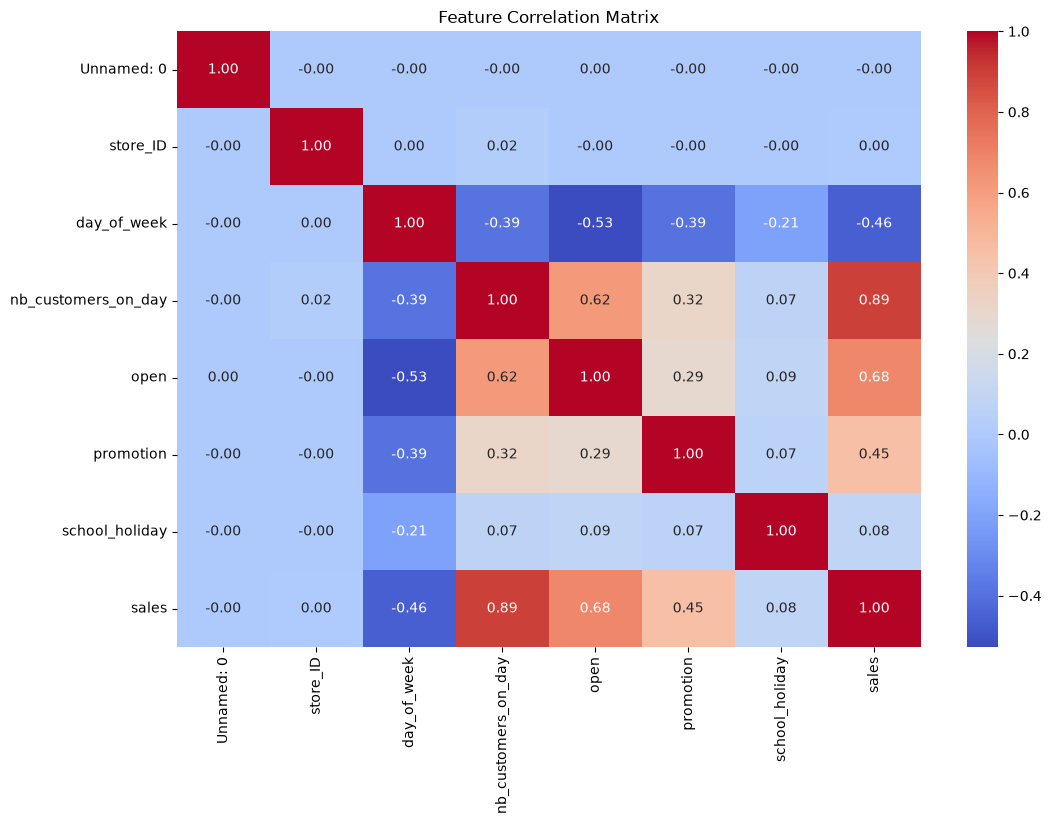

In [17]:
#analysis 
import matplotlib.pyplot as plt
import seaborn as sns

corr = df.corr(numeric_only=True)
print(corr)

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

## EDA Findings



Correlation analysis: nb_customers_on_day has the strongest positive correlation with sales (0.89), followed by open (0.68) and promotion (0.45). school_holiday has only a weak correlation with sales. However, day_of_week and store_ID are categorical variables represented numerically, so their Pearson correlations should not be interpreted as ordinary continuous relationships. Unnamed: 0 appears to be an index column and can be removed during data cleaning


 ## Data cleaning

In [18]:
#converting date datatype
df['date'] = pd.to_datetime(df['date'])
df['date'].dtype

df["month"] = df["date"].dt.month
df["day_of_month"] = df["date"].dt.day
df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)

print(df[["date", "month", "day_of_month", "week_of_year"]].head())



        date  month  day_of_month  week_of_year
0 2013-04-18      4            18            16
1 2015-04-11      4            11            15
2 2013-08-29      8            29            35
3 2013-05-28      5            28            22
4 2013-10-10     10            10            41


In [19]:
 #Define X and y

 df['date'] = pd.to_datetime(df['date'])
 df = df.sort_values('date')

 X = df.drop(columns=['sales', 'Unnamed: 0'])
 y = df['sales']
 print(X.shape)
 print(y.shape)

(640840, 11)
(640840,)


## Data Splitting

In [20]:

# Sort chronologically
df = df.sort_values(["date", "store_ID"]).reset_index(drop=True)

# Count rows on each date and find boundaries near 70% and 85%
rows_per_date = df.groupby("date").size()
cumulative_rows = rows_per_date.cumsum()

train_end = cumulative_rows.index[
    cumulative_rows.searchsorted(len(df) * 0.70)
]
val_end = cumulative_rows.index[
    cumulative_rows.searchsorted(len(df) * 0.85)
]

train_df = df[df["date"] <= train_end].copy()
val_df = df[(df["date"] > train_end) & (df["date"] <= val_end)].copy()
test_df = df[df["date"] > val_end].copy()

for name, part in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df),
]:
    print(
        name,
        "rows:", len(part),
        "percent:", round(len(part) / len(df) * 100, 2),
        "dates:", part["date"].min(), "to", part["date"].max()
    )

Train rows: 448873 percent: 70.04 dates: 2013-01-01 00:00:00 to 2014-10-19 00:00:00
Validation rows: 96392 percent: 15.04 dates: 2014-10-20 00:00:00 to 2015-03-17 00:00:00
Test rows: 95575 percent: 14.91 dates: 2015-03-18 00:00:00 to 2015-07-31 00:00:00


In [21]:
##Data Leakage Testing
for name, part in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df),
]:
    print(
        name,
        "| rows:", len(part),
        "| percent:", round(100 * len(part) / len(df), 2),
        "| first date:", part["date"].min(),
        "| last date:", part["date"].max(),
    )

print("Total rows in splits:", len(train_df) + len(val_df) + len(test_df))
print("Rows in original data:", len(df))

print(df.columns)

Train | rows: 448873 | percent: 70.04 | first date: 2013-01-01 00:00:00 | last date: 2014-10-19 00:00:00
Validation | rows: 96392 | percent: 15.04 | first date: 2014-10-20 00:00:00 | last date: 2015-03-17 00:00:00
Test | rows: 95575 | percent: 14.91 | first date: 2015-03-18 00:00:00 | last date: 2015-07-31 00:00:00
Total rows in splits: 640840
Rows in original data: 640840
Index(['Unnamed: 0', 'store_ID', 'day_of_week', 'date', 'nb_customers_on_day',
       'open', 'promotion', 'state_holiday', 'school_holiday', 'sales',
       'month', 'day_of_month', 'week_of_year'],
      dtype='str')


In [22]:

feature_cols = [
    "store_ID",
    "day_of_week",
    "open",
    "promotion",
    "state_holiday",
    "school_holiday",
    "month",
    "day_of_month",
    "week_of_year",
]
X_train = train_df[feature_cols].copy()
y_train = train_df["sales"].copy()

X_val = val_df[feature_cols].copy()
y_val = val_df["sales"].copy()

X_test = test_df[feature_cols].copy()
y_test = test_df["sales"].copy()

print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Training: (448873, 9) (448873,)
Validation: (96392, 9) (96392,)
Test: (95575, 9) (95575,)


In [23]:
X_train = pd.get_dummies(X_train, columns=["state_holiday"], dtype=int)
X_val = pd.get_dummies(X_val, columns=["state_holiday"], dtype=int)
X_test = pd.get_dummies(X_test, columns=["state_holiday"], dtype=int)

# Match validation and test columns to the training columns.
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(X_train.columns.tolist())
print(X_train.shape, X_val.shape, X_test.shape)

['store_ID', 'day_of_week', 'open', 'promotion', 'school_holiday', 'month', 'day_of_month', 'week_of_year', 'state_holiday_0', 'state_holiday_a', 'state_holiday_b', 'state_holiday_c']
(448873, 12) (96392, 12) (95575, 12)


## Defining Baseline Model

In [24]:
#Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

model = LinearRegression()
model.fit(X_train, y_train)

validation = model.predict(X_val)
predictions = model.predict(X_val)
r2_vlidation = r2_score(y_val, validation)  
r2 = r2_score(y_val, predictions)

print("R² (Validation):", r2_vlidation)
print("R² (Test):", r2)



R² (Validation): 0.5229055735873243
R² (Test): 0.5229055735873243


In [25]:
import joblib

joblib.dump(model, "regression.pkl")
print("Saved regression.pkl")

Saved regression.pkl


In [26]:
import joblib
from sklearn.metrics import mean_absolute_error, r2_score

saved_regression = joblib.load("../models/linear_regression.pkl")

regression_val_predictions = saved_regression.predict(X_val)

print("Loaded regression.pkl")
print("Validation MAE:",
      mean_absolute_error(y_val, regression_val_predictions))
print("Validation R²:",
      r2_score(y_val, regression_val_predictions))

Loaded regression.pkl
Validation MAE: 1827.9195822694742
Validation R²: 0.5229055735873243


In [27]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.08,
    tree_method="hist",
    random_state=42,
    n_jobs=4,
)

xgb_model.fit(X_train, y_train)

print("XGBoost training complete")

XGBoost training complete


In [28]:
import joblib

joblib.dump(xgb_model, "../models/xgboost.pkl")
print("Saved ../models/xgboost.pkl")

Saved ../models/xgboost.pkl


In [29]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
n_estimators=100,
random_state=42,
n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest R²:", rf_r2)

Random Forest R²: 0.8458599976554803
